In [19]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from neural_net import NeuralNet
import mushrooms as shroom
import graphics
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
mnist = fetch_openml('Fashion-MNIST', as_frame=False) #type:ignore
X, y = mnist.data, mnist.target # type:ignore
X = np.array(X)
y = np.astype(y, int)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y, random_state=42)

In [22]:
y_processed = np.zeros((len(y), 10))
for i, y_p in enumerate(y_processed):
    y_p[y[i]] =1

y = y_processed 
X = X/255
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [72]:
neural_net = NeuralNet((28**2, 1024, 10), learning_rate=0.005, random_state=42)
neural_net.layers[0].activation_method="ReLu"
neural_net.layers[0].initialize("He")
neural_net.layers[1].activation_method="ReLu"
#neural_net.layers[1].initialize("He")
neural_net.layers[-1].activation_method="softmax"
epochs = 20
losses, y_pred = neural_net.train(X_train, y_train, epochs, 256, validate=(X_test, y_test), binary=True, noise_randomization=True)

EPOCH: 1    LOSS: 0.0960984    LOSS CHANGE: 0    TEST ACCURACY: 0.791    TEST ACCURACY CHANGE: 0.791
EPOCH: 2    LOSS: 0.076297    LOSS CHANGE: -0.0198    TEST ACCURACY: 0.81    TEST ACCURACY CHANGE: 0.0189
EPOCH: 3    LOSS: 0.0726553    LOSS CHANGE: -0.003642    TEST ACCURACY: 0.815    TEST ACCURACY CHANGE: 0.00514
EPOCH: 4    LOSS: 0.0705474    LOSS CHANGE: -0.002108    TEST ACCURACY: 0.819    TEST ACCURACY CHANGE: 0.00329
EPOCH: 5    LOSS: 0.0691652    LOSS CHANGE: -0.001382    TEST ACCURACY: 0.824    TEST ACCURACY CHANGE: 0.00529
EPOCH: 6    LOSS: 0.0680677    LOSS CHANGE: -0.001098    TEST ACCURACY: 0.826    TEST ACCURACY CHANGE: 0.00214
EPOCH: 7    LOSS: 0.0673151    LOSS CHANGE: -0.0007526    TEST ACCURACY: 0.828    TEST ACCURACY CHANGE: 0.00229
EPOCH: 8    LOSS: 0.066418    LOSS CHANGE: -0.0008971    TEST ACCURACY: 0.83    TEST ACCURACY CHANGE: 0.0015
EPOCH: 9    LOSS: 0.0656872    LOSS CHANGE: -0.0007308    TEST ACCURACY: 0.831    TEST ACCURACY CHANGE: 0.00121
EPOCH: 10    LOS

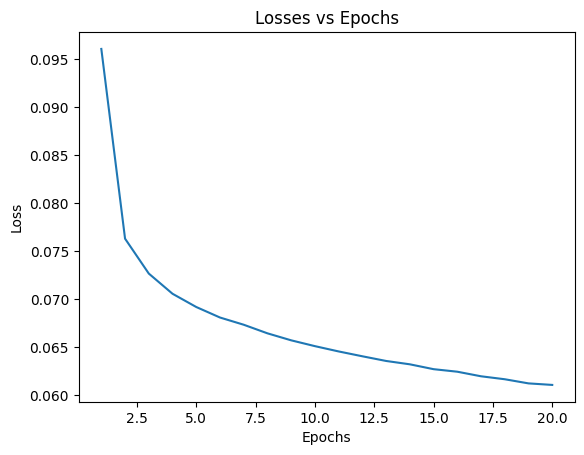

In [73]:
graphics.plot_losses(epochs, losses)

In [77]:
from sklearn.metrics import accuracy_score

labels = ["T-shirt", "Trousers", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]

y_pred = neural_net.predict(X_test)
y_pred = np.where(y_pred > 0.5, 1, 0)
print(f"Accuracy: {accuracy_score(y_pred, y_test)}")

Accuracy: 0.8416428571428571


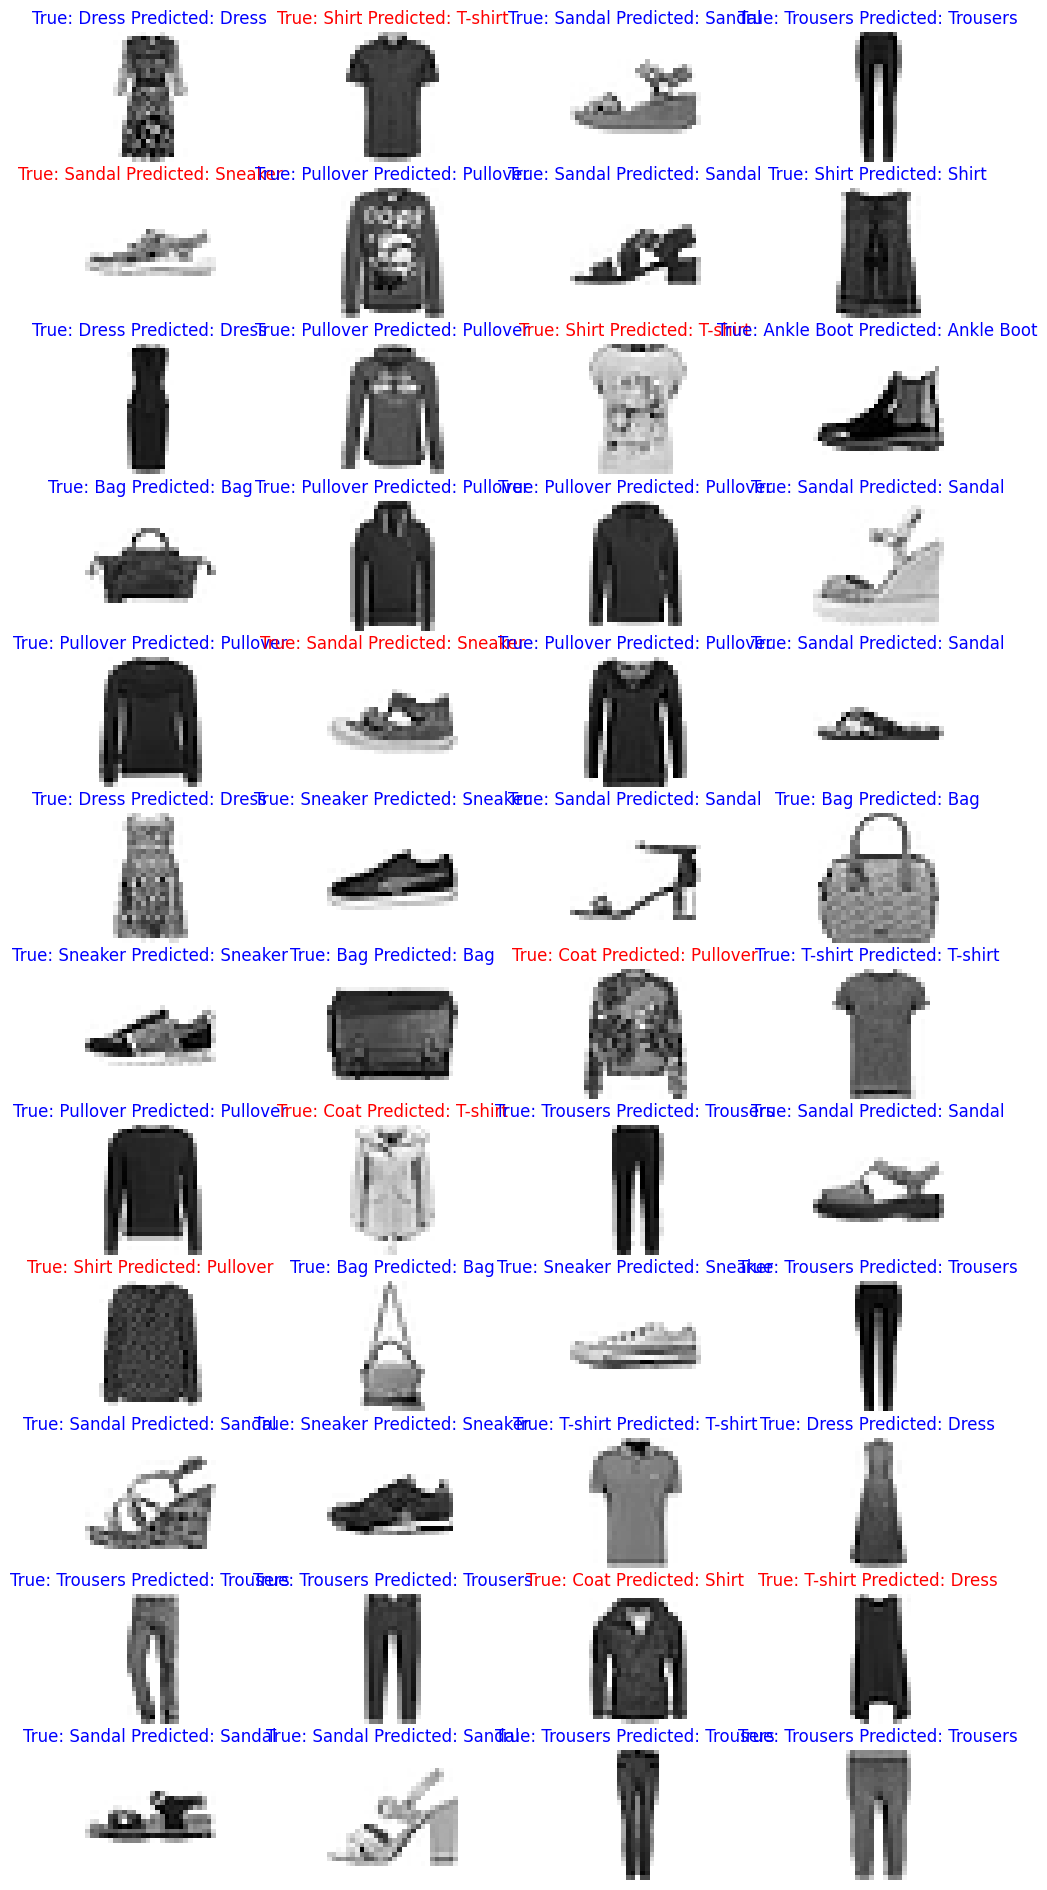

In [ ]:
def display_num(ax, X, i, true, pred):
    X_image = np.swapaxes(np.array(np.split(X, 28, axis=1)), 1, 0)
    ax.imshow(X_image[i], cmap="gray_r")
    ax.set_title(f'True: {true} Predicted: {pred}', c="blue" if true == pred else "red")
    ax.axis('off') # Hide axis ticks

k = 12
items_to_display = 4 * k

rows = k
cols = 4

fig, axs = plt.subplots(rows, cols, figsize=(12, 24))

for i in range(items_to_display):
    current_row = i // cols
    current_col = i % cols
    
    # Select the correct subplot axis
    ax = axs[current_row, current_col]
    display_num(ax, X_test, i, labels[y_test.argmax(axis=1)[i]], labels[y_pred.argmax(axis=1)[i]])
    #print(f"Prediction: {y_pred.argmax(axis=1)[i]}")